# Chapter 10. Data Aggregation and Group Operations
- After loading, merging, and preparing a dataset, you may need to compute group satistics or possibly *pivot tables** for reporting or visualization purposes.
- Pandas provides a flexible ***groupby*** interface, enabling you to slice, dice, and summarize datasets in a natural way.

> - **Split a pandas object** into pieces using one or more keys (in the form of **functions, arrays, or DataFrame column names**)
> - **Calculate group summary statistics**, like count, mean, or standard deviation, or a user-defined function
> - Apply **within-group** transformations or other manipulations, like **normalization, linear regression, rank, or subset selection**
> - Compute pivot tables and cross-tabulations
> - Perform **quantile analysis** and other statistical group analyses

In [1]:
import pandas as pd
import numpy as np

## 10.1 GroupBy Mechanics
- In the first stage of the process, data contained in a pandas object is **split** into group based on one or more **keys** that you provide. (a DataFrame can be grouped on its **rows *(axis="index")*** or its **columns *(axis="columns")***
- Once this is done, a function is **applied** to each group, producing a new value.
- Finally, the results of all those function applications are **combined** into a result object
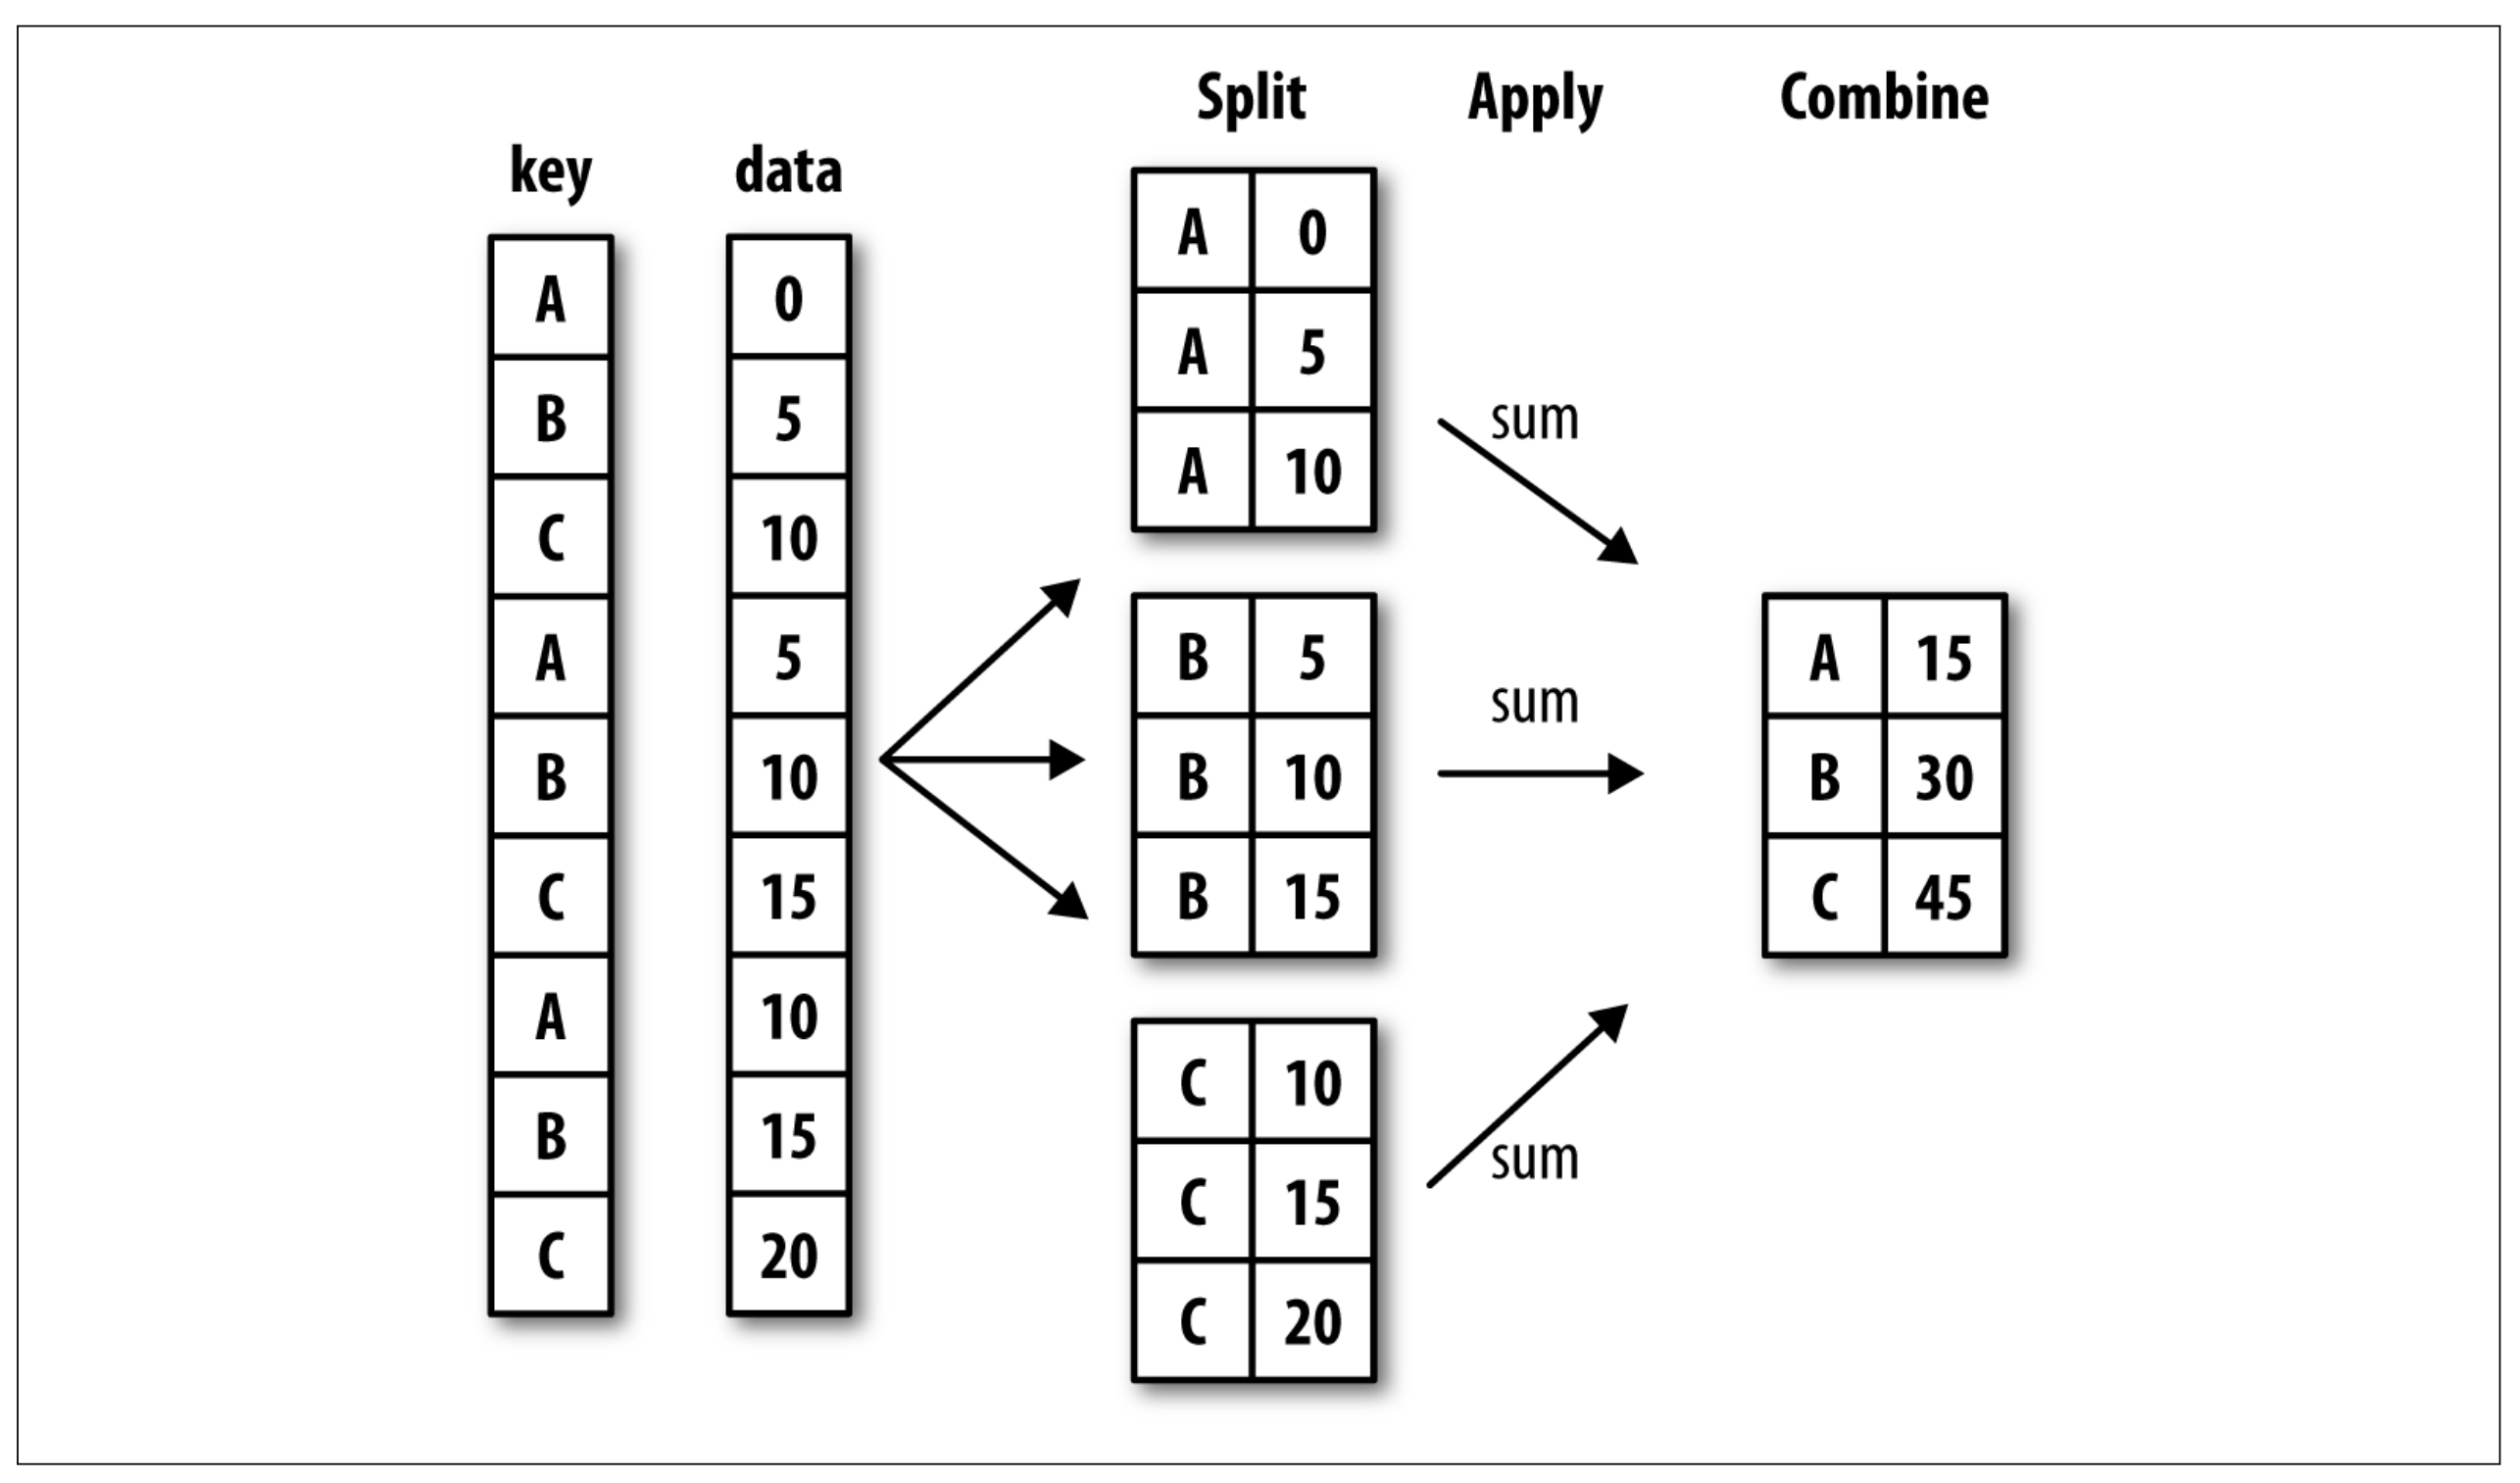

> - Each grouping key can take many forms, and the keys do not have to be all of the same type:
    - **A list or array of values** that is the **same length** as the axis being grouped
    - A value indicating a **column name in a DataFrame**
    - **A dict or Series** giving a correspondence between the **values on the axis being grouped and the group names**
    - **A function** to be invoked on the axis **index or the individual labels in the index**
> - Note that the latter three methods are shortcuts for producing an array of values to be used to split up the object.

In [11]:
df = pd.DataFrame({'key1':['a','a', None, 'b','b','a', None],
                   'key2':['one','two','one','two','one', None, 'one'],
                   'data1':np.random.randn(7),
                   'data2':np.random.randn(7)})
df

,key1,key2,data1,data2
0,a,one,0.543853,-0.105208
1,a,two,0.911211,-0.014443
2,None,one,0.822253,-1.207510
3,b,two,-0.033491,0.173178
4,b,one,1.419342,-1.510191
5,a,None,0.178249,1.292756
6,None,one,-2.538606,1.403690


> - To compute **the mean of the *data1*** column using the labels from ***key1***

In [49]:
# Case 1: Key로 Array ㅇl용
grouped = df['data1'].groupby(df['key1'])
grouped

- This **grouped** variable is now a ***GroupBy*** object
- It has **not actually computed anything yet** except for some intermediate data about the group key ***df['key1']***.

In [50]:
grouped.mean()

key1
a    0.492318
b   -0.507686
Name: data1, dtype: float64

-  The data (a Series) has been aggregated accroding to the group key, producing a new Seris that is now indexed by **the unique values in the *key1* column**.

> - If instead we had passed multiple arrays as a list:

In [51]:
# Case 1: Key로 Array ㅇl용, 이 경우 array의 array 즉 2차원
means = df['data1'].groupby([df['key1'],df['key2']]).mean()
means

key1  key2
a     one     0.852312
      two     0.352981
b     one    -0.696233
      two    -0.319139
Name: data1, dtype: float64

In [52]:
means.unstack()

key2,one,two
key1,,
a,0.852312,0.352981
b,-0.696233,-0.319139


> - In this example, the group keys are all Series, though they **could be any arrays of the right length**:

In [53]:
states = np.array(['OH','CA','CA','OH','OH','CA','OH'])
years = np.array([2005,2005,2006,2005,2006,2005,2006])

In [54]:
# Case 1: Key로 Array ㅇl용
df['data1'].groupby([states, years]).mean()

CA  2005    0.312322
    2006    0.483200
OH  2005    0.266586
    2006    0.061137
Name: data1, dtype: float64

In [55]:
# Case 2: Key로 Column name ㅇl용
df.groupby('key1').mean()

,data1,data2
key1,,
a,0.492318,0.507941
b,-0.507686,0.795929


In [56]:
df.groupby('key2').mean()

,data1,data2
key2,,
one,0.364446,-0.168834
two,0.016921,0.903877


In [57]:
df.groupby(['key1','key2']).mean()

data1     data2
key1 key2                    
a    one   0.852312 -0.191573
     two   0.352981  0.939969
b    one  -0.696233  0.724074
     two  -0.319139  0.867784

> - A generally useful GroupBy method is ***size***, which returns a Series containing group sizes:
> - Any missing values in a group key will be excluded from the results by default. This behavior can be disabled by passing ***dropna=False*** to groupby:

In [58]:
df.groupby(['key1','key2']).size()

key1  key2
a     one     1
      two     1
b     one     1
      two     1
dtype: int64

In [59]:
df.groupby(['key1','key2'], dropna=False).size()

key1  key2
a     one     1
      two     1
      NaN     1
b     one     1
      two     1
NaN   one     2
dtype: int64

> - A group function similar in spirit to ***size*** is ***count***, which computes the number of **nonnull values** in each group: 

In [60]:
df.groupby('key1').count()

,key2,data1,data2
key1,,,
a,2,3,3
b,2,2,2


### Iterating Over Groups
- The GroupBy object supports iteraion, generation a sequence of 2-tuples containing the group name along with the chunk of data.

In [61]:
for name, group in df.groupby('key1'):
    print(name)
    print(group)

a
  key1  key2     data1     data2
0    a   one  0.852312 -0.191573
1    a   two  0.352981  0.939969
5    a  None  0.271662  0.775426
b
  key1 key2     data1     data2
3    b  two -0.319139  0.867784
4    b  one -0.696233  0.724074


> - In the case of multiple keys, the first element in the tuple will be a tuple of key values:

In [62]:
for (k1,k2), group in df.groupby(['key1','key2']):
    print((k1,k2))
    print(group)

('a', 'one')
  key1 key2     data1     data2
0    a  one  0.852312 -0.191573
('a', 'two')
  key1 key2     data1     data2
1    a  two  0.352981  0.939969
('b', 'one')
  key1 key2     data1     data2
4    b  one -0.696233  0.724074
('b', 'two')
  key1 key2     data1     data2
3    b  two -0.319139  0.867784


> - You can choose to do whatever you want with the pieces of data.

In [63]:
pieces = {name: group for name, group in df.groupby('key1')} # dict화
pieces

{'a':   key1  key2     data1     data2
 0    a   one  0.852312 -0.191573
 1    a   two  0.352981  0.939969
 5    a  None  0.271662  0.775426,
 'b':   key1 key2     data1     data2
 3    b  two -0.319139  0.867784
 4    b  one -0.696233  0.724074}

In [64]:
pieces['b']

,key1,key2,data1,data2
3,b,two,-0.319139,0.867784
4,b,one,-0.696233,0.724074


> - By default, ***groupby*** groups on ***axis='index'***, but you can **group on any of the other axes**. 
> - For example, we could group the columns of our example *df* here by **whether they start with *'key'* or *'data'***: 

In [65]:
grouped = df.groupby({'key1':'key', 'key2':'key',
                      'data1':'data', 'data2':'data'}, axis='columns')

In [66]:
for group_key, group_values in grouped:
    print(group_key)
    print(group_values)

data
      data1     data2
0  0.852312 -0.191573
1  0.352981  0.939969
2  0.483200 -0.650091
3 -0.319139  0.867784
4 -0.696233  0.724074
5  0.271662  0.775426
6  0.818507 -0.557745
key
   key1  key2
0     a   one
1     a   two
2  None   one
3     b   two
4     b   one
5     a  None
6  None   one


### Selecting a Column or Subset of Columns
- Indexing a GroupBy object created **from a DataFrame with a column name or array of column names** has the effect of column subsetting for aggreation **(syntatic sugar!!)**

In [80]:
# Series화
df.groupby('key1')['data1'] # = df['data1'].groupby(df['key1'])

In [82]:
# DataFrame화
df.groupby('key1')[['data2']] # = df[['data2']].groupby(df['key1'])

> - To compute means for just the *data2* column and get the result as a **DataFrame [['data2']]**

In [83]:
df.groupby(['key1','key2'])[['data2']].mean()

data2
key1 key2          
a    one  -0.191573
     two   0.939969
b    one   0.724074
     two   0.867784

In [85]:
df.groupby(['key1','key2'])['data2'].mean()

key1  key2
a     one    -0.191573
      two     0.939969
b     one     0.724074
      two     0.867784
Name: data2, dtype: float64

### Grouping with Dictionaries and Series
- Grouping information may exist in a form other than an array
- 본 절에서는 Dict와 Series 사용 예시임

In [2]:
people = pd.DataFrame(np.random.randn(5,5),
                      columns=['a','b','c','d','e'],
                      index=['Joe','Steve','Wes','Jim','Travis'])
people.iloc[2:3,[1,2]] = np.nan
people

,a,b,c,d,e
Joe,0.618053,0.206805,1.074390,-2.192918,-0.203247
Steve,0.335936,0.120095,-0.806411,-1.950335,1.016447
Wes,1.894201,NaN,NaN,0.677898,-1.988034
Jim,-0.607420,-0.708070,0.312065,0.703048,-1.505681
Travis,-0.564561,-2.074366,-0.112002,0.203795,-0.292813


In [4]:
mapping = {'a':'red','b':'red','c':'blue','d':'blue','e':'red','f':'orange'}
mapping

{'a': 'red', 'b': 'red', 'c': 'blue', 'd': 'blue', 'e': 'red', 'f': 'orange'}

> - You could construct an array from this dict to pass to *groupby*

In [9]:
by_column = people.groupby(mapping, axis='columns')
by_column.sum()

,blue,red
Joe,-1.118528,0.621610
Steve,-2.756746,1.472478
Wes,0.677898,-0.093834
Jim,1.015114,-2.821171
Travis,0.091793,-2.931741


> - The same functionality holds for Series, which can be viewed as a fixed-size mapping:

In [10]:
map_series = pd.Series(mapping)
people.groupby(map_series, axis='columns').count()

,blue,red
Joe,2,3
Steve,2,3
Wes,1,2
Jim,2,3
Travis,2,3


### Grouping with Functions
- **Using Python functions is a more generic way** of defining a group mapping compared with a dict or Seris
- Any function passed as a group key will **be called once per index value, with the return values being used as the group names**.

> - 앞의 DF에서 사람 이름(index) 길이에 따른 grouping:

In [7]:
people.groupby(len).sum()

,a,b,c,d,e
3,1.904834,-0.501265,1.386455,-0.811971,-3.696962
5,0.335936,0.120095,-0.806411,-1.950335,1.016447
6,-0.564561,-2.074366,-0.112002,0.203795,-0.292813


> - **Mixing functions with *arrays, dict, or Series* is not a problem as everything gets converted to arrays internally**

In [8]:
key_list = ['one','one','one','two','two']
people.groupby([len, key_list]).min()

a         b         c         d         e
3 one  0.618053  0.206805  1.074390 -2.192918 -1.988034
  two -0.607420 -0.708070  0.312065  0.703048 -1.505681
5 one  0.335936  0.120095 -0.806411 -1.950335  1.016447
6 two -0.564561 -2.074366 -0.112002  0.203795 -0.292813

### Grouping by Index Levels
- A final convenience for hierarchically indexed datasets is **the ability to aggregate using one of the levels of an axis index:**

In [5]:
columns = pd.MultiIndex.from_arrays([['US','US','US','JP','JP'],
                                    [1,3,5,1,3]],
                                   names=['cty','tenor'])
hier_df = pd.DataFrame(np.random.randn(4,5), columns=columns)
hier_df

cty          US                            JP          
tenor         1         3         5         1         3
0     -1.588944  0.601062 -1.661754  1.558688 -0.613887
1      1.063876  0.414475 -0.939992 -0.745207  0.100187
2     -2.382626 -0.155609 -0.039613 -0.200867 -0.217366
3     -0.887011  1.487300 -0.998011 -1.859678  0.679745

> - To group by level, pass the level number or name using the level keyword:

In [7]:
hier_df.groupby(level='cty', axis="columns").count()

cty,JP,US
0,2,3
1,2,3
2,2,3
3,2,3
